# RNN vs LSTM vs GRU

In [30]:
# IMPORTS
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time
from collections import Counter


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print("GPU name :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU name : Tesla T4


In [31]:
# CONFIGS
model_type = "LSTM"
max_len = 200
vocab_size = 25000
embedding_dim = 100
hidden = 128
bidir = True
num_layer = 2
dropout = 0.4
batch_size = 64
epochs = 10
lr = 0.0001
min_freq = 2

print(f"Model : {model_type}")

Model : LSTM


### Loading the Dataset

In [32]:
# Load the dataset
df = pd.read_csv('/content/IMDB Dataset.csv')
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [33]:
print(f"Shape of Data : {df.shape}")

Shape of Data : (50000, 2)


In [34]:
# Check the data Quality
print(f'Null values : {df.isnull().sum().sum()}')
print(f"Duplicate rows: {df.duplicated().sum()}")

Null values : 0
Duplicate rows: 418


In [35]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (49582, 2)


In [36]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [37]:
# Text Clean
def clean_text(text):
  text = re.sub(r'<[^>]+>', '', text)
  text = text.lower()
  text = re.sub(r"[^a-z0-9\s']", '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text
df['clean_review'] = df['review'].apply(clean_text)

In [38]:
print("BEFORE:", df['review'].iloc[1][:200])
print("AFTER :", df['clean_review'].iloc[1][:200])

BEFORE: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece
AFTER : a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are ex


### Tokenize and Build Vocab

In [39]:
def tokenize(text):
  return text.split()

tokenize('I love pakistan')

['I', 'love', 'pakistan']

In [40]:
word_count = Counter()
for review in df['clean_review']:
  word_count.update(tokenize(review))

print(f"Total unique words: {len(word_count):,}")

Total unique words: 235,817


In [41]:
vocab = {'<PAD>': 0, '<UNK>': 1}

most_common = word_count.most_common(vocab_size - 2)
for word, count in most_common:
  if count >= 2:
    vocab[word] = len(vocab)

print(f"Vocabulary size    : {len(vocab):,}")
print(f"Coverage (approx)  : top {vocab_size} words")

Vocabulary size    : 25,000
Coverage (approx)  : top 25000 words


In [42]:
print(f"\nSample vocab entries:")
sample = list(vocab.items())[555:559]
for word, idx in sample:
    print(f"  {word}: {idx}")


Sample vocab entries:
  wonder: 555
  looked: 556
  coming: 557
  blood: 558


In [43]:
def tokenize(text):
  return text.split()

word_count = Counter()
for review in df['clean_review']:
  word_count.update(tokenize(review))

vocab = {'<PAD>':0, '<UNK>':1}
most_common = word_count.most_common(vocab_size - 2)
for word, count in most_common:
  if count >=2:
    vocab[word] = len(vocab)

# Encode the text

In [44]:
def encode(text, vocab, max_len):
  token = tokenize(text)
  indices = [vocab.get(t,1) for t in token]
  indices = indices[:max_len]
  indices = indices + [0] * (max_len - len(indices))
  return indices

In [45]:
print("Encoding reviews...")
df['sentiment'] = df['sentiment'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].map({"positive":1, "negative":0})
y = df['sentiment'].tolist()
X = [encode(review, vocab, max_len) for review in df['clean_review']]

# Train / Validation / Test split (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {len(X_train):,} samples")
print(f"Val   : {len(X_val):,} samples")
print(f"Test  : {len(X_test):,} samples")

# Verify class balance in each split
print(f"\nTrain positive: {sum(y_train)/len(y_train):.1%}")
print(f"Val   positive: {sum(y_val)/len(y_val):.1%}")
print(f"Test  positive: {sum(y_test)/len(y_test):.1%}")

Encoding reviews...
Train : 34,707 samples
Val   : 7,437 samples
Test  : 7,438 samples

Train positive: 50.2%
Val   positive: 50.2%
Test  positive: 50.2%


# Dataset and DataLoader

In [46]:
class IMDBDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.long)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)
test_dataset = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 543
Val batches   : 117
Test batches  : 117


# Define Model

In [47]:
class SentimentModel(nn.Module):
  def __init__ (self, model_type, vocab_size, embedding_dim, hidden_size, num_layer, num_classes, bidirectional, dropout):
    super().__init__()
    self.model_type = model_type
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.dropout = nn.Dropout(dropout)
    rnn_dropout = dropout if num_layer > 1 else 0

    if model_type == "RNN":
      self.rnn = nn.RNN(embedding_dim, hidden_size, num_layer, batch_first=True, bidirectional=bidirectional, dropout=rnn_dropout)
    elif model_type == "LSTM":
      self.rnn = nn.LSTM(embedding_dim, hidden_size, num_layer,batch_first=True, bidirectional=bidirectional,dropout=rnn_dropout)
    elif model_type == "GRU":
      self.rnn = nn.GRU(embedding_dim, hidden_size, num_layer,batch_first=True, bidirectional=bidirectional,dropout=rnn_dropout)

    fc_input = hidden_size * 2 if bidirectional else hidden_size
    self.fc = nn.Linear(fc_input, num_classes)

  def forward(self, x): # Corrected: method name should be 'forward'
    embedded = self.dropout(self.embedding(x))
    if self.model_type == "LSTM":
      output, (hidden, cell) = self.rnn(embedded)
    else:
      output, hidden = self.rnn(embedded)

    if self.rnn.bidirectional:
      last = torch.cat((hidden[-2], hidden[-1]), dim=1)
    else:
      last = hidden[-1]

    last = self.dropout(last)
    return self.fc(last)

In [48]:
model = SentimentModel(model_type=model_type, vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden,
  num_classes=2, num_layer=num_layer, bidirectional=bidir, dropout=dropout).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model      : {model_type}")
print(f"Parameters : {total_params:,}")
print(f"\nArchitecture:")
print(model)

Model      : LSTM
Parameters : 3,131,298

Architecture:
SentimentModel(
  (embedding): Embedding(25000, 100, padding_idx=0)
  (dropout): Dropout(p=0.4, inplace=False)
  (rnn): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


# Loss and Optimizer

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [50]:
def train_one_epoch(model, loader, criterion, optimizer):
  model.train()
  total_loss = 0
  correct = 0

  for X_batch, y_batch in loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    predictions = model(X_batch)
    loss = criterion(predictions, y_batch)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    total_loss += loss.item()
    correct += (predictions.argmax(1) == y_batch).sum().item()

  return  total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0
  correct = 0

  with torch.no_grad():
    for X_batch, y_batch in loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      preds = model(X_batch)
      loss  = criterion(preds, y_batch)
      total_loss += loss.item()
      correct    += (preds.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)
print("Function Ready!")

Function Ready!


In [51]:
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

best_val_acc = 0.0
start_time   = time.time()

print(f"Training {model_type} for {epochs} epochs...\n")

for epoch in range(epochs):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - t0

    print(f"Epoch {epoch+1:02d}/{epochs} ({epoch_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc


total_time = time.time() - start_time
print(f"\nTotal training time : {total_time:.1f}s")
print(f"Best Val Accuracy   : {best_val_acc:.4f}")

Training LSTM for 10 epochs...

Epoch 01/10 (16.5s) | Train Loss: 0.6902  Acc: 0.5283 | Val Loss: 0.6751  Acc: 0.5775
Epoch 02/10 (17.4s) | Train Loss: 0.6394  Acc: 0.6366 | Val Loss: 0.6282  Acc: 0.6524
Epoch 03/10 (17.4s) | Train Loss: 0.5752  Acc: 0.7056 | Val Loss: 0.6047  Acc: 0.7108
Epoch 04/10 (16.5s) | Train Loss: 0.5351  Acc: 0.7389 | Val Loss: 0.4836  Acc: 0.7757
Epoch 05/10 (16.3s) | Train Loss: 0.5003  Acc: 0.7623 | Val Loss: 0.4854  Acc: 0.7853
Epoch 06/10 (17.0s) | Train Loss: 0.4806  Acc: 0.7702 | Val Loss: 0.4697  Acc: 0.7962
Epoch 07/10 (16.9s) | Train Loss: 0.4591  Acc: 0.7884 | Val Loss: 0.4250  Acc: 0.8179
Epoch 08/10 (16.9s) | Train Loss: 0.4524  Acc: 0.7930 | Val Loss: 0.4311  Acc: 0.8080
Epoch 09/10 (16.7s) | Train Loss: 0.4290  Acc: 0.8038 | Val Loss: 0.4970  Acc: 0.7927
Epoch 10/10 (16.6s) | Train Loss: 0.4214  Acc: 0.8087 | Val Loss: 0.4282  Acc: 0.8268

Total training time : 168.2s
Best Val Accuracy   : 0.8268


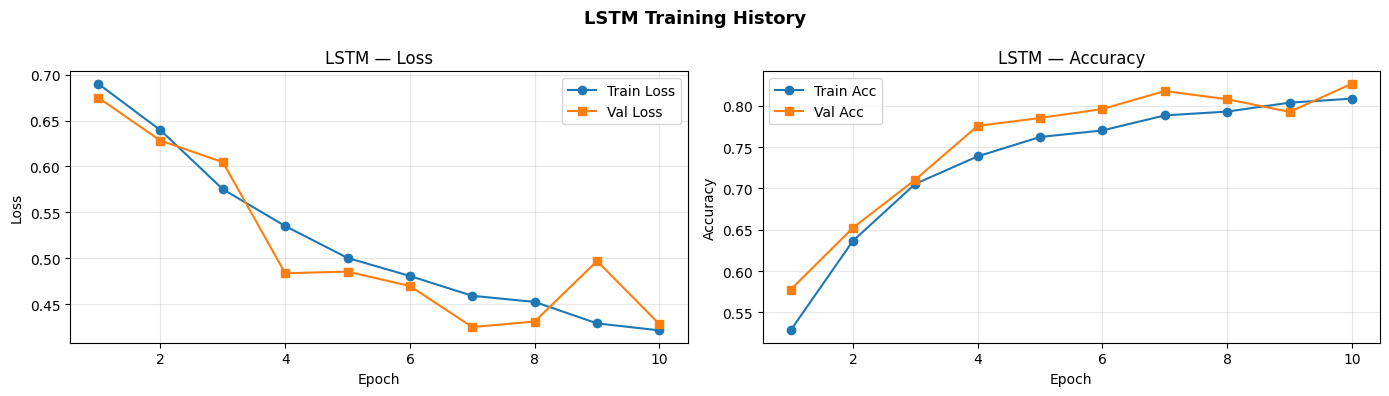

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, epochs + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title(f'{model_type} — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   marker='s')
axes[1].set_title(f'{model_type} — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{model_type} Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  LSTM — TEST SET RESULTS
  Accuracy : 0.8162  (81.62%)
  F1 Score : 0.8146

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.72      0.80      3705
    Positive       0.77      0.91      0.83      3733

    accuracy                           0.82      7438
   macro avg       0.83      0.82      0.81      7438
weighted avg       0.83      0.82      0.81      7438



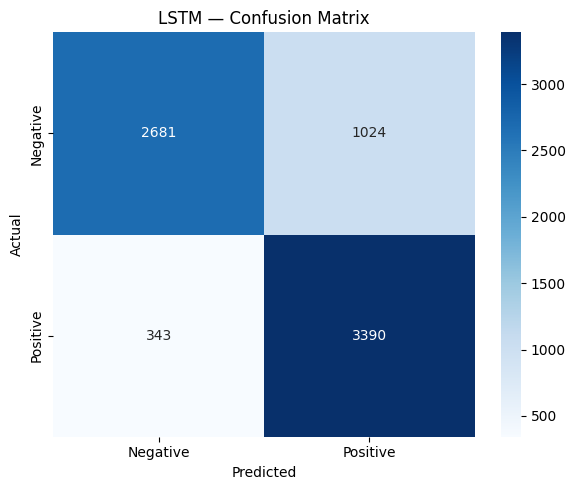

In [53]:
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix)
import seaborn as sns
# Load best model weights
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')

print(f"{'='*45}")
print(f"  {model_type} — TEST SET RESULTS")
print(f"{'='*45}")
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 Score : {f1:.4f}")
print(f"{'='*45}\n")
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'{model_type} — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Misclassified Examples

In [54]:
errors = []
model.eval()

with torch.no_grad():
    for i, (X_batch, y_batch) in enumerate(test_loader):
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu()

        for j in range(len(y_batch)):
            if preds[j] != y_batch[j]:
                global_idx = i * batch_size + j
                if global_idx < len(X_test):
                    errors.append({
                        'review'   : df['clean_review'].iloc[
                                       len(X_train) + len(X_val) + global_idx
                                     ][:150],
                        'actual'   : 'Positive' if y_batch[j] == 1 else 'Negative',
                        'predicted': 'Positive' if preds[j]   == 1 else 'Negative',
                    })

print(f"Total misclassified: {len(errors)}")
print(f"Error rate         : {len(errors)/len(X_test):.2%}\n")
print("Sample misclassified reviews:\n")

for i, err in enumerate(errors[:5]):
    print(f"Example {i+1}:")
    print(f"  Review   : {err['review']}...")
    print(f"  Actual   : {err['actual']}")
    print(f"  Predicted: {err['predicted']}")
    print()

Total misclassified: 1367
Error rate         : 18.38%

Sample misclassified reviews:

Example 1:
  Review   : soultaker was written by and starred vivian schilling it also starred joe estevez gregg thomsen and robert d'zar as the angel of deaththe story begins...
  Actual   : Negative
  Predicted: Positive

Example 2:
  Review   : i watched this movie for a project on love please tell nicolas cage to learn what it would feel like to be his character and then reread the lines he'...
  Actual   : Negative
  Predicted: Positive

Example 3:
  Review   : i read most of the comments here were everybody saw only the flaws of the movie i agree the director it's not kuprik the actors are not oscar winners ...
  Actual   : Negative
  Predicted: Positive

Example 4:
  Review   : and it is this film i imagine that if indeed there is a negative afterlife damned souls are tied to a rather uncomfortable couch and forced to watch t...
  Actual   : Negative
  Predicted: Positive

Example 5:
  Review   

In [55]:
def predict(text, model, vocab, max_len):
    model.eval()
    cleaned = clean_text(text)
    encoded = encode(cleaned, vocab, max_len)
    x       = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(x)
        probs  = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()

    label = "Positive 😊" if pred == 1 else "Negative 😞"
    conf  = probs[0][pred].item()
    print(f"[{model_type}]")
    print(f"Text      : {text[:80]}")
    print(f"Sentiment : {label}  ({conf:.2%} confidence)\n")

# Test with your own sentences
predict("This movie was absolutely brilliant. Best film I've seen in years.",
        model, vocab, max_len)
predict("Terrible waste of time. The acting was awful and the plot made no sense.",
        model, vocab, max_len)
predict("I totally hate this worst movie.",
        model, vocab, max_len)

[LSTM]
Text      : This movie was absolutely brilliant. Best film I've seen in years.
Sentiment : Positive 😊  (94.39% confidence)

[LSTM]
Text      : Terrible waste of time. The acting was awful and the plot made no sense.
Sentiment : Negative 😞  (97.92% confidence)

[LSTM]
Text      : I totally hate this worst movie.
Sentiment : Negative 😞  (87.59% confidence)



In [57]:
results = {
    'Model'      : ['RNN',  'LSTM', 'GRU'],
    'Params'     : [2658210, 3131298,  2973602],
    'Test Acc'   : [0.6609,    0.82,    0.8035   ],
    'F1 Score'   : [0.5386,    0.8045,    0.7886   ],
    'Train Time' : [50.5,     165.1,      101.8     ]
}

results_df = pd.DataFrame(results)
print("=" * 50)
print("  MODEL COMPARISON TABLE")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

  MODEL COMPARISON TABLE
Model  Params  Test Acc  F1 Score  Train Time
  RNN 2658210    0.6609    0.5386        50.5
 LSTM 3131298    0.8200    0.8045       165.1
  GRU 2973602    0.8035    0.7886       101.8
